In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 4.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

## LOAD DATA

In [ ]:
DATASET_GDRIVE_ID = "1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx"  # CarDD_release.zip
ZIP_PATH = "/content/CarDD_release.zip"
EXTRACT_DIR = "/content/CarDD_release"

!wget --no-check-certificate \
  "https://drive.usercontent.google.com/download?id={DATASET_GDRIVE_ID}&export=download&confirm=t" \
  -O {ZIP_PATH}

import os
size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"Downloaded size: {size_mb:.1f} MB")
assert size_mb > 100

--2026-09-10 08:36:16--  https://drive.usercontent.google.com/download?id=1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx&export=download&confirm=t
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.142.132, 2607:f8b0:400e:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.142.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6045392762 (5.6G) [application/octet-stream]
Saving to: ‘/content/CarDD_release.zip’

/content/CarDD_rele 100%[===================>]   5.63G  42.0MB/s    in 86s     

2026-09-10 08:37:43 (66.7 MB/s) - ‘/content/CarDD_release.zip’ saved [6045392762/6045392762]

Downloaded size: 5765.3 MB


In [ ]:
# unzip the dataset
!unzip -q {ZIP_PATH} -d {EXTRACT_DIR}

# check the structure before we touch anything
!find {EXTRACT_DIR} -maxdepth 3 -type d

/content/CarDD_release
/content/CarDD_release/CarDD_release
/content/CarDD_release/CarDD_release/CarDD_SOD
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-VAL
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TE
/content/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR
/content/CarDD_release/CarDD_release/CarDD_COCO
/content/CarDD_release/CarDD_release/CarDD_COCO/val2017
/content/CarDD_release/CarDD_release/CarDD_COCO/train2017
/content/CarDD_release/CarDD_release/CarDD_COCO/annotations
/content/CarDD_release/CarDD_release/CarDD_COCO/test2017


In [ ]:
# quick look at the COCO annotation file before converting
import json

DATA_ROOT = "/content/CarDD_release/CarDD_release/CarDD_COCO"

with open(f"{DATA_ROOT}/annotations/instances_train2017.json") as f:
    coco_train = json.load(f)

print("Top level keys:", list(coco_train.keys()))
print("Number of images:", len(coco_train["images"]))
print("Number of annotations:", len(coco_train["annotations"]))
print("Categories:")
for cat in coco_train["categories"]:
    print(" ", cat["id"], "-", cat["name"])

# check if annotations have segmentation (polygons) or just bboxes
sample_ann = coco_train["annotations"][0]
print("\nSample annotation keys:", list(sample_ann.keys()))
print("Has segmentation field:", "segmentation" in sample_ann)

Top level keys: ['licenses', 'info', 'categories', 'images', 'annotations']
Number of images: 2816
Number of annotations: 6211
Categories:
  1 - dent
  2 - scratch
  3 - crack
  4 - glass shatter
  5 - lamp broken
  6 - tire flat

Sample annotation keys: ['id', 'image_id', 'category_id', 'segmentation', 'area', 'bbox', 'iscrowd', 'attributes']
Has segmentation field: True


In [ ]:
# convert COCO polygon annotations to YOLO segmentation format (.txt per image)
!pip install -q ultralytics pycocotools

from ultralytics.data.converter import convert_coco

convert_coco(
    labels_dir=f"{DATA_ROOT}/annotations",
    save_dir=f"{DATA_ROOT}/yolo_labels",
    use_segments=True,   # we need polygons, not just boxes, since this is a seg task
    use_keypoints=False,
    cls91to80=False      # keep our own 6 classes, don't remap to COCO's 80
)

!find {DATA_ROOT}/yolo_labels -maxdepth 3 -type d

Annotations /content/CarDD_release/CarDD_release/CarDD_COCO/annotations/instances_test2017.json: 100% ━━━━━━━━━━━━ 374/374 3.1Kit/s 0.1s
Annotations /content/CarDD_release/CarDD_release/CarDD_COCO/annotations/instances_train2017.json: 100% ━━━━━━━━━━━━ 2816/2816 3.0Kit/s 0.9s
Annotations /content/CarDD_release/CarDD_release/CarDD_COCO/annotations/instances_val2017.json: 100% ━━━━━━━━━━━━ 810/810 3.0Kit/s 0.3s
COCO data converted successfully.
Results saved to /content/CarDD_release/CarDD_release/CarDD_COCO/yolo_labels
/content/CarDD_release/CarDD_release/CarDD_COCO/yolo_labels
/content/CarDD_release/CarDD_release/CarDD_COCO/yolo_labels/labels
/content/CarDD_release/CarDD_release/CarDD_COCO/yolo_labels/labels/val2017
/content/CarDD_release/CarDD_release/CarDD_COCO/yolo_labels/labels/train2017
/content/CarDD_release/CarDD_release/CarDD_COCO/yolo_labels/labels/test2017
/content/CarDD_release/CarDD_release/CarDD_COCO/yolo_labels/images


In [ ]:
# now arrange everything into the folder layout YOLO expects:
# images/train, images/val, images/test + labels/train, labels/val, labels/test
import os, shutil

YOLO_ROOT = "/content/cardd_yolo_seg"
os.makedirs(YOLO_ROOT, exist_ok=True)

splits_map = {
    "train2017": "train",
    "val2017": "val",
    "test2017": "test"
}

for coco_split, yolo_split in splits_map.items():
    img_src = f"{DATA_ROOT}/{coco_split}"
    lbl_src = f"{DATA_ROOT}/yolo_labels/labels/{coco_split}"

    img_dst = f"{YOLO_ROOT}/images/{yolo_split}"
    lbl_dst = f"{YOLO_ROOT}/labels/{yolo_split}"

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    # copy images
    for fname in os.listdir(img_src):
        shutil.copy(os.path.join(img_src, fname), img_dst)

    # copy labels (if this split's folder exists)
    if os.path.exists(lbl_src):
        for fname in os.listdir(lbl_src):
            shutil.copy(os.path.join(lbl_src, fname), lbl_dst)

    n_img = len(os.listdir(img_dst))
    n_lbl = len(os.listdir(lbl_dst)) if os.path.exists(lbl_dst) else 0
    print(f"{yolo_split}: {n_img} images, {n_lbl} labels")

train: 2816 images, 2816 labels
val: 810 images, 810 labels
test: 374 images, 374 labels


In [ ]:
# sanity check: do image names actually match label names?
def get_stems(folder):
    return set(os.path.splitext(f)[0] for f in os.listdir(folder))

for split in ["train", "val", "test"]:
    img_stems = get_stems(f"{YOLO_ROOT}/images/{split}")
    lbl_stems = get_stems(f"{YOLO_ROOT}/labels/{split}")
    matched = img_stems & lbl_stems
    print(f"{split}: {len(matched)} matched out of {len(img_stems)} images")

train: 2816 matched out of 2816 images
val: 810 matched out of 810 images
test: 374 matched out of 374 images


#### Train --> 2816 img
#### Val --> 810 img
#### Test --> 374 img

### AVG Size of img 1086 × 611

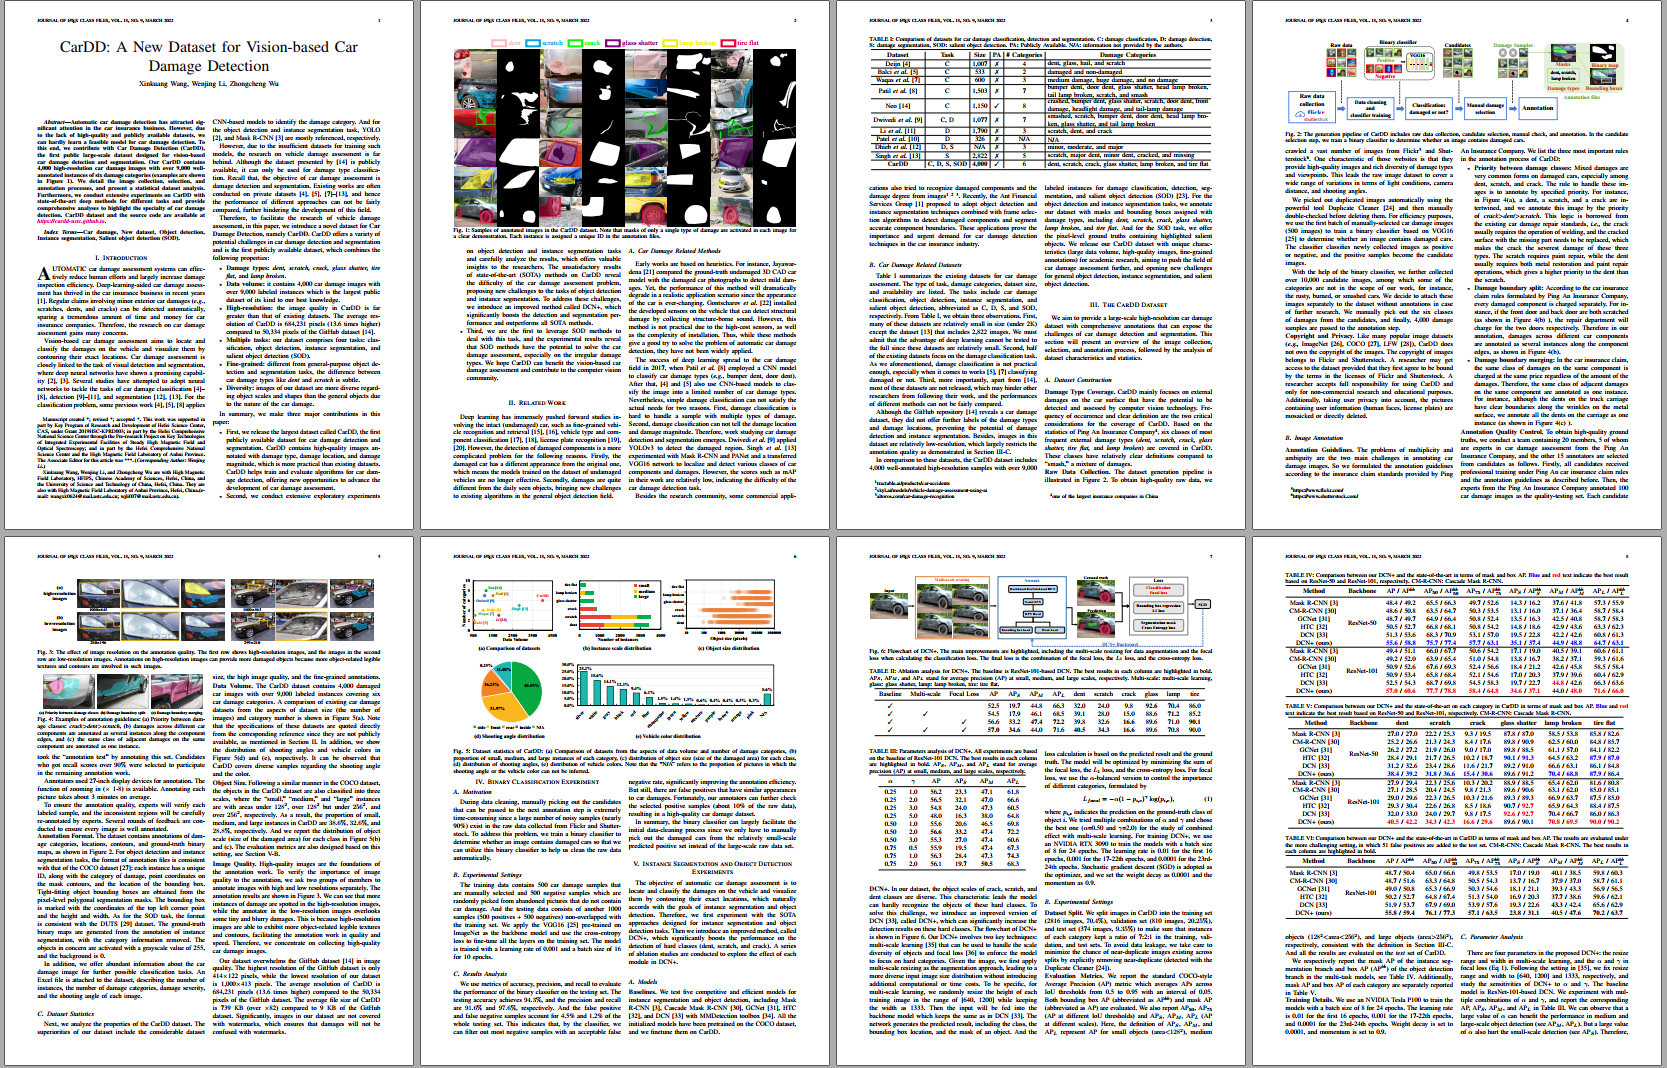

In [ ]:
# write the data.yaml file that YOLO needs for training
yaml_content = """
path: /content/cardd_yolo_seg
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat
"""

with open(f"{YOLO_ROOT}/data.yaml", "w") as f:
    f.write(yaml_content)

print(open(f"{YOLO_ROOT}/data.yaml").read())


path: /content/cardd_yolo_seg
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



In [ ]:
# final check that ultralytics can read the dataset correctly
from ultralytics.data.utils import check_det_dataset

check_det_dataset(f"{YOLO_ROOT}/data.yaml")

{'path': PosixPath('/content/cardd_yolo_seg'),
 'train': '/content/cardd_yolo_seg/images/train',
 'val': '/content/cardd_yolo_seg/images/val',
 'test': '/content/cardd_yolo_seg/images/test',
 'names': {0: 'dent',
  1: 'scratch',
  2: 'crack',
  3: 'glass shatter',
  4: 'lamp broken',
  5: 'tire flat'},
 'yaml_file': '/content/cardd_yolo_seg/data.yaml',
 'nc': 6,
 'channels': 3}

## The Dataset: CarDD

We used the CarDD (Car Damage Detection) dataset, which is a dataset built specifically for detecting car damage, published as part of a research paper (unlike most datasets we usually pull from Roboflow).

The dataset covers 6 damage types:
- dent
- scratch
- crack
- glass shatter
- lamp broken
- tire flat

### Original Data Format

The dataset zip contains two parts:
- **CarDD_SOD**: for salient object detection, we didn't use this part
- **CarDD_COCO**: this is what we used — 2816 training images, 810 validation images, and 374 test images

The annotations were in COCO json format (each annotation file has bounding boxes plus segmentation polygons for every damaged region in every image), not YOLO's .txt format, which is what's needed for training.

### Converting to YOLO Format

To train YOLO segmentation models, we went through these steps:

1. **Converting the annotations**: we used ultralytics' `convert_coco` utility to turn the COCO json files into YOLO segmentation .txt files (each line has the class id plus the polygon coordinates of the damaged region).

2. **Reorganizing the folders**: we arranged images and labels into the layout YOLO expects:

3. **data.yaml file**: we wrote the config file that points to the image/label paths and lists the 6 class names, which is what YOLO takes as input for training or evaluation.

After these steps, the dataset was ready to be used directly with any YOLO segmentation model (v8, v11, v26...) without any further changes.

---

## LOAD 4 MODELS

### YOLO-8n-seg ---> 25 epoch (Used In Deployment Production)

In [ ]:
# download model 1: YOLOv8n-seg, trained for 25 epochs
# this is the model currently used in production/deployment
!pip install -q gdown

!gdown --folder "https://drive.google.com/drive/folders/18b6VTQnRohTpT7N1IlkePsA-Fj5gPbZl?usp=drive_link" -O /content/models/yolo8n_25ep

Retrieving folder contents
Processing file 11B0sT1zAK5qWRnYpEmPCTe1tOwtosXlE best.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=11B0sT1zAK5qWRnYpEmPCTe1tOwtosXlE
To: /content/models/yolo8n_25ep/best.pt
100% 6.76M/6.76M [00:00<00:00, 56.0MB/s]
Download completed


In [ ]:
# find the actual weight file inside whatever folder structure gdown pulled down
import glob

model1_candidates = glob.glob("/content/models/yolo8n_25ep/**/*.pt", recursive=True)
print(model1_candidates)

['/content/models/yolo8n_25ep/best.pt']


In [ ]:
MODEL_YOLO8n_25_epoch_PATH = "/content/models/yolo8n_25ep/best.pt"  # YOLOv8n-seg, 25 epochs (production model)

In [ ]:
model_yolo8n_25_epoch = YOLO(MODEL_YOLO8n_25_epoch_PATH)

print("Model 1 (YOLOv8n-seg, 25 epochs):")
print("Classes:", model_yolo8n_25_epoch.names)
print("Task:", model_yolo8n_25_epoch.task)

Model 1 (YOLOv8n-seg, 25 epochs):
Classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
Task: segment


---

### YOLO-8n-seg ---> 75 epochs (50 epoch Continued)

In [ ]:
# download model 2: YOLOv8n-seg, trained for 50 epochs
!gdown --folder "https://drive.google.com/drive/folders/13-Hhxjc2lpFTDFb3v1boLPhiZN7yI_tf?usp=drive_link" -O /content/models/yolo8n_50ep

Retrieving folder contents
Processing file 1amcgl0qPXEWgKDPBfGAJz_VADrwxYePf best.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1amcgl0qPXEWgKDPBfGAJz_VADrwxYePf
To: /content/models/yolo8n_50ep/best.pt
100% 6.77M/6.77M [00:00<00:00, 192MB/s]
Download completed


In [ ]:
# find the weight file inside it
model2_candidates = glob.glob("/content/models/yolo8n_50ep/**/*.pt", recursive=True)
print(model2_candidates)

['/content/models/yolo8n_50ep/best.pt']


In [ ]:
MODEL_YOLO8_75_epoch_PATH = "/content/models/yolo8n_75ep/best.pt"  # YOLOv8n-seg, 75 epochs

In [ ]:
model_yolo8n_75_epoch = YOLO(MODEL_YOLO8_75_epoch_PATH)

print("Model 2 (YOLOv8n-seg, 75 epochs):")
print("Classes:", model_yolo8n_75_epoch.names)
print("Task:", model_yolo8n_75_epoch.task)

Model 2 (YOLOv8n-seg, 50 epochs):
Classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
Task: segment


---

### YOLO-11m-seg ---> 40 epoch





In [ ]:
# download model 3: YOLO11m-seg, trained for 40 epochs
import os
os.makedirs("/content/models/yolo11m_40ep", exist_ok=True)

!gdown "https://drive.google.com/uc?id=19hXMKNPvlcnTskXkq9Qe5iaCNuAjy82x" -O /content/models/yolo11m_40ep/best.pt

Downloading...
From (original): https://drive.google.com/uc?id=19hXMKNPvlcnTskXkq9Qe5iaCNuAjy82x
From (redirected): https://drive.google.com/uc?id=19hXMKNPvlcnTskXkq9Qe5iaCNuAjy82x&confirm=t&uuid=aba03edc-148a-4a5b-b61b-fa4ee224a8e5
To: /content/models/yolo11m_40ep/best.pt
100% 45.1M/45.1M [00:00<00:00, 70.1MB/s]


In [ ]:
MODEL_YOLO11m_40_epoch_PATH = "/content/models/yolo11m_40ep/best.pt"  # YOLO11m-seg, 40 epochs

model_yolo11m_40_epoch = YOLO(MODEL_YOLO11m_40_epoch_PATH)

print("Model 3 (YOLO11m-seg, 40 epochs):")
print("Classes:", model_yolo11m_40_epoch.names)
print("Task:", model_yolo11m_40_epoch.task)

Model 3 (YOLO11m-seg, 40 epochs):
Classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
Task: segment


---

### YOLO-26m-seg ---> 35 epoch


In [ ]:
# download model 4: YOLO26m-seg, trained for 35 epochs
import os
os.makedirs("/content/models/yolo26m_35ep", exist_ok=True)

!gdown "https://drive.google.com/uc?id=1HXJkUET-29bJkoovHVZYSmSUEyqBqDsY" -O /content/models/yolo26m_35ep/best.pt

Downloading...
From (original): https://drive.google.com/uc?id=1HXJkUET-29bJkoovHVZYSmSUEyqBqDsY
From (redirected): https://drive.google.com/uc?id=1HXJkUET-29bJkoovHVZYSmSUEyqBqDsY&confirm=t&uuid=c1c15977-e2db-46d3-a389-9341217f1e48
To: /content/models/yolo26m_35ep/best.pt
100% 217M/217M [00:02<00:00, 96.0MB/s]


In [ ]:
MODEL_YOLO26m_35_epoch_PATH = "/content/models/yolo26m_35ep/best.pt"  # YOLO26m-seg, 35 epochs

model_yolo26m_35_epoch = YOLO(MODEL_YOLO26m_35_epoch_PATH)

print("Model 4 (YOLO26m-seg, 35 epochs):")
print("Classes:", model_yolo26m_35_epoch.names)
print("Task:", model_yolo26m_35_epoch.task)

Model 4 (YOLO26m-seg, 35 epochs):
Classes: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}
Task: segment


---

## Why YOLO


---

## Which paper models are built on which base architecture

| Paper model | Built on |
|---|---|
| Cascade Mask R-CNN | Mask R-CNN |
| GCNet | Mask R-CNN |
| HTC | Mask R-CNN |
| DCN | Mask R-CNN |
| DCN+ | Mask R-CNN (via DCN) |
| U2-Net | UNET |
| CSNet | UNET (indirectly) |
| PoolNet | UNET (indirectly) |
| SGL-KRN | UNET (indirectly) |

## The 5 base architectures, in short

**R-CNN**: Proposes thousands of candidate regions using a traditional algorithm (selective search), then runs a separate CNN on each region to classify it. Very slow since it repeats the same computation thousands of times.

 ---

**Fast R-CNN**: Computes features for the whole image once, then extracts each region's features from that single map (RoI Pooling) instead of recomputing from scratch. Much faster than R-CNN.

 ---

**Faster R-CNN**: Replaces the traditional region-proposal algorithm with a trainable neural network (RPN) that proposes regions itself. Makes the whole model end-to-end, faster, and more accurate.

 ---

**Mask R-CNN**: Faster R-CNN + an extra branch that outputs a pixel-level mask for each object, not just a bounding box. First strong model to do instance segmentation properly.

 ---

**U-Net**: Encoder-decoder architecture shaped like a "U" — downsamples (encoder) the image to extract features, then upsamples (decoder) it back, with skip connections that preserve fine boundary detail.

---

## How YOLO Works (Anchor Boxes)

YOLO splits the image into a grid, and each grid cell is responsible for detecting any object whose center falls inside it.

**Anchor boxes**: instead of predicting one box per cell, each cell has several predefined box shapes (anchors) with different sizes/aspect ratios — e.g. wide, tall, square. For each anchor, the model predicts: is there an object here, what class is it, and a small adjustment to fit the anchor exactly onto the real object. This is easier to learn than predicting raw coordinates from scratch.

All of this happens in a **single pass** over the whole image (single-stage), unlike Faster R-CNN which needs a separate region-proposal stage first. A final filtering step (Non-Max Suppression) removes duplicate boxes on the same object.

**Note**: modern YOLO versions (v8, v11, used here) actually moved to an **anchor-free** approach — predicting the object's center and size directly, without predefined anchor shapes. Same core idea (grid + single-pass prediction), just simpler and with fewer hyperparameters to tune.

## Backend Summary

The backend is a FastAPI service that combines a YOLO segmentation model with Gemini (LLM) to detect and report car damage.

**Flow**: a client uploads an image → YOLO detects damage regions (type, location, size) → the annotated image plus YOLO's findings are sent to Gemini → Gemini judges the severity of each damage by looking at the photo, and generates a full structured repair report (steps, tools, time, cost in EGP) → the API returns everything as JSON.

**Division of responsibility**: YOLO handles *where* and *what* (spatial detection, classification), while Gemini handles *how bad* (severity, judged visually) and turns the raw detections into a human-readable technician's report. Each module in the codebase has a single responsibility — API layer, CV inference, LLM reporting, and config — kept separate for clarity and maintainability.

Gemini calls use a fallback chain (tries a lighter model first, falls back to a stronger one on failure/timeout) so a single model outage doesn't break the whole request.

In [ ]:
# Car-Damage-Detection-API/
# │
# ├── main.py                      # FastAPI app, HTTP endpoints (entry point)
# │   ├── GET  /                   # root check
# │   ├── GET  /health             # health check
# │   ├── POST /analyze            # image -> findings + full report
# │   └── POST /analyze-image      # image -> annotated image only
# │
# ├── config.py                    # environment vars, YOLO model loader (singleton),
# │   │                             # Gemini client setup, model fallback chain list
# │   └── get_model()              # loads model_yolo8.pt once
# │
# ├── inference.py                 # computer vision pipeline
# │   ├── _decode_image()          # bytes -> OpenCV/numpy image
# │   ├── _normalize_class_name()  # cleans YOLO class label formatting
# │   ├── _run_yolo()              # runs segmentation, builds findings + annotated image
# │   └── run_pipeline()           # orchestrates: decode -> YOLO -> (optional) Gemini
# │
# ├── llm.py                       # LLM reporting layer
# │   ├── DAMAGE_CLASSES            # the 6 canonical damage labels
# │   ├── VLM_TECHNICIAN_PROMPT_TEMPLATE   # prompt sent to Gemini
# │   ├── REPORT_SCHEMA             # forces structured JSON output from Gemini
# │   ├── _call_gemini()            # single model call, with timeout
# │   └── get_gemini_report()       # tries fallback chain of Gemini models
# │
# ├── Dockerfile                   # container build (Python 3.12-slim, uv, non-root user)
# ├── pyproject.toml / requirements.txt   # dependencies
# └── .env                         # secrets (GEMINI_API_KEY, etc.)

---

---

### SRC/utils/config.py



In [ ]:
import os
import logging
from dotenv import load_dotenv
from ultralytics import YOLO
from google import genai

load_dotenv()

logger = logging.getLogger(__name__)

# --- Environment variables ---
APP_NAME = os.getenv("APP_NAME")
VERSION = os.getenv("VERSION")
SECRET_API_KEY = os.getenv("SECRET_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
SRC_PATH = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
MODEL_PATH = os.path.join(SRC_PATH, 'artifacts', 'model_yolo8.pt')


REQUEST_TIMEOUT_SECONDS = 15

# --- Gemini client (new google-genai SDK) ---
gemini_client = genai.Client(api_key=GEMINI_API_KEY)

GEMINI_MODEL_FALLBACK_CHAIN = [
    "gemini-3.5-flash-lite",
    "gemini-3.5-flash"
]

# --- YOLO model (lazy-loaded singleton) ---
_model = None

def get_model():
    global _model
    if _model is None:
        _model = YOLO(MODEL_PATH)
    return _model

### SRC/utils/inference.py

In [ ]:
import cv2
import numpy as np
from .config import get_model
from .llm import get_gemini_report


def _normalize_class_name(name: str) -> str:
    """
    YOLO class names may come with different spacing/case than CarDD's
    canonical labels -- normalize so they line up with DAMAGE_CLASSES in llm.py.

    Example: "Glass_Shatter" -> "glass shatter"
    """
    return name.strip().lower().replace("_", " ")


def _decode_image(image_bytes: bytes):
    """
    Convert raw uploaded file bytes (still JPEG/PNG-compressed) into an
    actual pixel array that OpenCV/YOLO can work with.

    bytes  -> np.frombuffer -> raw numbers (not yet a real image)
            -> cv2.imdecode -> real image as numpy array (H, W, 3) in BGR order
    """
    array = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(array, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError("Could not decode image bytes -- unsupported or corrupt image.")
    return image


def _run_yolo(image: np.ndarray, conf: float = 0.35):
    """
    Runs the segmentation model on the image. Returns:
      - findings: list of dicts (damage_type, bbox, area_pct_of_image) -- no
        severity/cost here, that's Gemini's job once it sees the image.
      - annotated: a copy of the image with each damage region highlighted
        and labeled, ready to send to Gemini and to show the user.
    """
    model = get_model()

    # Original image size in pixels. Needed later to resize masks and to
    # calculate what % of the image each damage area covers.
    height, width = image.shape[:2]

    # Run YOLO on the image. [0] because predict() returns a list of
    results = model.predict(image, conf=conf, verbose=False)[0]

    findings = []
    # We draw on a COPY of the original image so we don't touch the source.
    annotated = image.copy()

    # results.masks is None if the model found no damage at all.
    if results.masks is not None:
        boxes = results.boxes.xyxy.cpu().numpy()        # bounding boxes, already at original image size
        class_indices = results.boxes.cls.cpu().numpy() # which damage class each detection belongs to
        masks = results.masks.data.cpu().numpy()        # segmentation masks, at the MODEL's internal size (smaller than the image)

        # Loop once per detected damage region (a photo can have several).
        for box, class_idx, mask in zip(boxes, class_indices, masks):
            class_name = _normalize_class_name(model.names[int(class_idx)])

            # --- AREA CALCULATION ---

            mask_full = cv2.resize(mask, (width, height))

            area_pct = round(100 * float(mask_full.sum()) / (width * height), 3)

            findings.append({
                "damage_type": class_name,
                "bbox": [int(v) for v in box],
                "area_pct_of_image": area_pct,
            })

            # --- DRAWING (manual, with OpenCV -- not YOLO's built-in plot) ---
            color = (0, 0, 255)  # red, in BGR order (OpenCV's color order)

            # 1. Paint a semi-transparent red patch over the damaged pixels.
            overlay = annotated.copy()
            overlay[mask_full > 0.5] = color                       # color only the "damage" pixels
            annotated = cv2.addWeighted(overlay, 0.4, annotated, 0.6, 0)  # blend: 40% red overlay + 60% original

            # 2. Draw a rectangle around the bounding box.
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

            # 3. Write the damage type as a label above the box.
            cv2.putText(annotated, class_name, (x1, max(y1 - 8, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return findings, annotated


def run_pipeline(image_bytes: bytes, conf: float = 0.35, include_report: bool = True) -> dict:
    """
    The main entry point called by main.py for both endpoints.

    Steps:
      1. decode the uploaded bytes into a real image
      2. run YOLO -> get findings + a highlighted (annotated) image
      3. re-encode the annotated image back to JPEG bytes (for the HTTP response / Gemini)
      4. optionally ask Gemini to turn the findings + image into a full report
    """
    image = _decode_image(image_bytes)
    findings, annotated = _run_yolo(image, conf=conf)


    success, encoded = cv2.imencode(".jpg", annotated)
    if not success:
        raise ValueError("Failed to encode annotated image.")
    annotated_bytes = encoded.tobytes()


    report = None
    if include_report:
        report = get_gemini_report(annotated_bytes, findings)

    return {
        "findings": findings,
        "annotated_image": annotated_bytes,
        "report": report,
    }

### SRC/utils/llm.py

In [ ]:
import json
import logging
import time
import concurrent.futures

from google.genai import types as genai_types

from .config import gemini_client, GEMINI_MODEL_FALLBACK_CHAIN, REQUEST_TIMEOUT_SECONDS

logger = logging.getLogger(__name__)

# --- CarDD damage classes (must match the YOLO model's class names exactly) ---
DAMAGE_CLASSES = ["dent", "scratch", "crack", "glass shatter", "lamp broken", "tire flat"]

# --- Prompt template ---
VLM_TECHNICIAN_PROMPT_TEMPLATE = (
    "You are an experienced car repair technician working in Egypt. "
    "A computer-vision pipeline (YOLOv8-seg) has already detected and localized "
    "the damage on this vehicle. The attached photo is annotated with the detected "
    "region(s) highlighted, and the JSON below lists exactly what the detector found "
    "-- damage type/label, severity, bounding box, and the percentage of the image "
    "each damaged area covers (derived from its segmentation mask):\n\n"
    "{findings_json}\n\n"
    "Treat this JSON as ground truth for WHICH damages exist, WHERE they are, and "
    "their type/size -- do not invent additional damage it doesn't mention, "
    "and do not dismiss damage it does mention. Look closely at the highlighted "
    "region(s) in the photo yourself and judge the SEVERITY of each damage based on "
    "what you actually see (depth, spread, how structurally serious it looks) -- the "
    "detector does not provide severity, that judgment is yours to make. Then write a "
    "full technician's report.\n\n"
    "All monetary values MUST be realistic current Egyptian market prices. "
    "For every cost, return a MIN and MAX value in Egyptian Pounds (EGP). "
    "Use plain numbers only, without currency symbols or the word 'EGP' inside "
    "the numbers. The total range should be consistent with the technician and "
    "parts ranges. "
    "estimated_repair_time_hours must be a plain number of hours (decimals allowed, "
    "e.g. 1.5)."
)

# --- Response schema (Gemini formats the report itself, no manual parsing needed) ---
REPORT_SCHEMA = {
    "type": "object",
    "properties": {
        "damage_assessment": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "damage_type": {"type": "string", "enum": DAMAGE_CLASSES},
                    "location_on_vehicle": {"type": "string"},
                    "severity": {"type": "string", "enum": ["minor", "moderate", "severe"]},
                    "description": {"type": "string"},
                },
                "required": [
                    "damage_type",
                    "location_on_vehicle",
                    "severity",
                    "description",
                ],
            },
        },
        "repair_steps": {
            "type": "array",
            "items": {"type": "string"},
        },
        "tools_and_equipment_needed": {
            "type": "array",
            "items": {"type": "string"},
        },
        "estimated_repair_time_hours": {
            "type": "number",
        },

        # Money is returned as a realistic Egyptian Pound range
        "technician_service_cost_egp": {
            "type": "object",
            "properties": {
                "min": {"type": "number"},
                "max": {"type": "number"},
            },
            "required": ["min", "max"],
        },

        "equipment_and_parts_cost_egp": {
            "type": "object",
            "properties": {
                "min": {"type": "number"},
                "max": {"type": "number"},
            },
            "required": ["min", "max"],
        },

        "total_estimated_cost_egp": {
            "type": "object",
            "properties": {
                "min": {"type": "number"},
                "max": {"type": "number"},
            },
            "required": ["min", "max"],
        },

        "notes": {
            "type": "string",
        },
    },
    "required": [
        "damage_assessment",
        "repair_steps",
        "tools_and_equipment_needed",
        "estimated_repair_time_hours",
        "technician_service_cost_egp",
        "equipment_and_parts_cost_egp",
        "total_estimated_cost_egp",
        "notes",
    ],
}

def _call_gemini(model_name: str, image_bytes: bytes, prompt: str):
    """Single call to one Gemini model. Raises on failure/timeout."""
    image_part = genai_types.Part.from_bytes(data=image_bytes, mime_type="image/jpeg")

    request_config = genai_types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=REPORT_SCHEMA,
    )

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(
            gemini_client.models.generate_content,
            model=model_name,
            contents=[image_part, prompt],
            config=request_config,
        )
        response = future.result(timeout=REQUEST_TIMEOUT_SECONDS)

    return response.text


def get_gemini_report(image_bytes: bytes, findings: list[dict]) -> dict:
    prompt = VLM_TECHNICIAN_PROMPT_TEMPLATE.format(
        findings_json=json.dumps(findings, ensure_ascii=False)
    )

    last_error = None
    pipeline_start = time.time()

    for model_name in GEMINI_MODEL_FALLBACK_CHAIN:
        attempt_start = time.time()
        try:
            raw_text = _call_gemini(model_name, image_bytes, prompt)
            elapsed = time.time() - attempt_start
            total_elapsed = time.time() - pipeline_start
            logger.info(f"[TIMING] Gemini success with {model_name} in {elapsed:.2f}s (total chain: {total_elapsed:.2f}s)")
            print(f"[TIMING] Gemini success with {model_name} in {elapsed:.2f}s (total chain: {total_elapsed:.2f}s)")
            return json.loads(raw_text)
        except concurrent.futures.TimeoutError:
            elapsed = time.time() - attempt_start
            logger.warning(f"[TIMING] Gemini TIMEOUT on {model_name} after {elapsed:.2f}s")
            print(f"[TIMING] Gemini TIMEOUT on {model_name} after {elapsed:.2f}s")
            last_error = f"Timeout: {model_name}"
        except Exception as e:
            elapsed = time.time() - attempt_start
            logger.warning(f"[TIMING] Gemini FAILED on {model_name} after {elapsed:.2f}s: {e}")
            print(f"[TIMING] Gemini FAILED on {model_name} after {elapsed:.2f}s: {e}")
            last_error = e

    total_elapsed = time.time() - pipeline_start
    print(f"[TIMING] ALL models failed. Total chain time: {total_elapsed:.2f}s")
    raise RuntimeError(f"All Gemini models failed. Last error: {last_error}")

### main.py

In [ ]:
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import Response
from SRC.utils.inference import run_pipeline

app = FastAPI(
    title="Car Damage Detection API",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


@app.get("/")
def root():
    return {
        "message": "Car Damage Detection API is running"
    }


@app.get("/health")
def health():
    return {
        "status": "ok"
    }


@app.post("/analyze")
async def analyze(file: UploadFile = File(...)):

    try:
        image_bytes = await file.read()

        if not image_bytes:
            raise HTTPException(
                status_code=400,
                detail="No image uploaded"
            )

        result = run_pipeline(image_bytes)

        return {
            "success": True,
            "findings": result["findings"],
            "report": result["report"]
        }

    except Exception as e:
        raise HTTPException(
            status_code=500,
            detail=str(e)
        )


@app.post("/analyze-image")
async def analyze_image(file: UploadFile = File(...)):

    try:
        image_bytes = await file.read()

        if not image_bytes:
            raise HTTPException(
                status_code=400,
                detail="No image uploaded"
            )

        result = run_pipeline(image_bytes, include_report=False)

        return Response(
            content=result["annotated_image"],
            media_type="image/jpeg"
        )

    except Exception as e:
        raise HTTPException(
            status_code=500,
            detail=str(e)
        )

### Dockerfile

In [ ]:
FROM python:3.12-slim

WORKDIR /app

RUN pip install --no-cache-dir uv

COPY pyproject.toml .
RUN uv pip install --system --no-cache -r pyproject.toml

COPY . .

RUN useradd -m -u 1000 user
ENV HOME=/home/user
RUN chown -R user:user /app
USER user

EXPOSE 7860

CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]

### pyproject.toml

In [ ]:
[project]
name = "Car-Damage-detector"
version = "1.0.0"
description = "Car Damage Detector — API"
requires-python = "==3.12.*"
dependencies = [
    "uvicorn==0.49.0",
    "fastapi[standard]==0.139.0",
    "ultralytics==8.4.142",
    "pydantic==2.13.4",
    "python-dotenv==1.2.2",
    "python-multipart==0.0.32",
    "opencv-python-headless==4.10.0.84",
    "Pillow==10.4.0",
    "google-genai==1.28.0",
]

[tool.uv]
override-dependencies = [
    "opencv-python; sys_platform == 'never'",
]

----

----

# EVALUATION

In [ ]:
# evaluate all 4 models on the same test set for a fair comparison
DATA_YAML = f"{YOLO_ROOT}/data.yaml"

models = {
    "YOLOv8n-seg (25 epochs)": model_yolo8n_25_epoch,
    "YOLOv8n-seg (75 epochs)": model_yolo8n_75_epoch,
    "YOLO11m-seg (40 epochs)": model_yolo11m_40_epoch,
    "YOLO26m-seg (35 epochs)": model_yolo26m_35_epoch,
}

results_summary = []

for name, model in models.items():
    print(f"\nEvaluating: {name}")
    metrics = model.val(data=DATA_YAML, split="test", verbose=False)

    results_summary.append({
        "Model": name,
        "mAP50 (box)": round(metrics.box.map50, 4),
        "mAP50-95 (box)": round(metrics.box.map, 4),
        "mAP50 (mask)": round(metrics.seg.map50, 4),
        "mAP50-95 (mask)": round(metrics.seg.map, 4),
        "Precision (mask)": round(metrics.seg.mp, 4),
        "Recall (mask)": round(metrics.seg.mr, 4),
    })


Evaluating: YOLOv8n-seg (25 epochs)
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-seg summary (fused): 85 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 363.5±551.4 MB/s, size: 508.3 KB)
val: Scanning /content/cardd_yolo_seg/labels/test... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 586.3it/s 0.6s
val: New cache created: /content/cardd_yolo_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.6s/it 1:49
                   all        374        785      0.655      0.657      0.686      0.528      0.659      0.647      0.683        0.5
Speed: 6.6ms preprocess, 240.8ms inference, 0.0ms loss, 8.7ms postprocess per image
Results saved to /content/runs/segment/val

Evaluating: YOLOv8n-seg (50 epochs)
Ultralytics 8.4.146 🚀 Python-3.13.15 torc

In [ ]:
# turn it into a clean table
import pandas as pd

df = pd.DataFrame(results_summary)


In [ ]:
# NOTE: model 2 (YOLOv8n-seg) was continued training on top of model 1,
# so its real epoch count is 25 + 50 = 75 total epochs, not a fresh 50-epoch run

results_summary = [
    {"Model": "YOLOv8n-seg (25 epochs)", "mAP50 (box)": 0.6861, "mAP50-95 (box)": 0.5284,
     "mAP50 (mask)": 0.6826, "mAP50-95 (mask)": 0.4999, "Precision (mask)": 0.6591, "Recall (mask)": 0.6468},
    {"Model": "YOLOv8n-seg (75 epochs total)", "mAP50 (box)": 0.7179, "mAP50-95 (box)": 0.5608,
     "mAP50 (mask)": 0.7153, "mAP50-95 (mask)": 0.5225, "Precision (mask)": 0.7066, "Recall (mask)": 0.7055},
    {"Model": "YOLO11m-seg (40 epochs)", "mAP50 (box)": 0.7681, "mAP50-95 (box)": 0.6071,
     "mAP50 (mask)": 0.7562, "mAP50-95 (mask)": 0.5696, "Precision (mask)": 0.7601, "Recall (mask)": 0.6918},
    {"Model": "YOLO26m-seg (35 epochs)", "mAP50 (box)": 0.5984, "mAP50-95 (box)": 0.4033,
     "mAP50 (mask)": 0.5800, "mAP50-95 (mask)": 0.4030, "Precision (mask)": 0.5896, "Recall (mask)": 0.5927},
]

import pandas as pd
df = pd.DataFrame(results_summary)
df.sort_values("mAP50-95 (mask)", ascending=False).reset_index(drop=True)

,Model,mAP50 (box),mAP50-95 (box),mAP50 (mask),mAP50-95 (mask),Precision (mask),Recall (mask)
0,YOLO11m-seg (40 epochs),0.7681,0.6071,0.7562,0.5696,0.7601,0.6918
1,YOLOv8n-seg (75 epochs total),0.7179,0.5608,0.7153,0.5225,0.7066,0.7055
2,YOLOv8n-seg (25 epochs),0.6861,0.5284,0.6826,0.4999,0.6591,0.6468
3,YOLO26m-seg (35 epochs),0.5984,0.4033,0.5800,0.4030,0.5896,0.5927


## mAP50 vs mAP50-95

mAP measures detection accuracy using IoU (overlap between predicted and true mask).

- **mAP50**: correct if overlap ≥ 50% (lenient — checks if the model found the damage roughly).
- **mAP50-95**: average across stricter thresholds (0.50 → 0.95) — checks if the model got the exact shape/edges right, not just the rough location.

**Rule of thumb**: mAP50 = "did it find the damage?", mAP50-95 = "did it outline it precisely?"
A big gap between the two means the model locates damage well but isn't precise on its exact boundary — expected here since damage shapes (scratches, cracks) are irregular.

## IoU (Intersection over Union)
Measures how much a predicted box overlaps with the ground truth box: **IoU = Intersection ÷ Union**. Ranges 0 (no overlap) to 1 (perfect match). Used to define whether a detection counts as correct (e.g., mAP50 = correct if IoU ≥ 0.5).

## Non-Max Suppression (NMS)
Removes duplicate boxes predicted for the same object. It keeps the box with the highest confidence, then deletes any nearby box whose IoU with it is above a threshold, and repeats until only the best box per object remains.

## Comparison with the Original CarDD Paper

The CarDD paper tested five two-stage detectors (Mask R-CNN, Cascade Mask R-CNN, GCNet, HTC, DCN) and proposed their own improved method, DCN+, which achieved the best results — a mask AP (mAP50-95) of 57.0 using a ResNet-101 backbone with multi-scale learning and focal loss.

For reference, here are the paper's key numbers (ResNet-101 backbone, their strongest setting):

| Method | Mask AP (mAP50-95) | Mask AP50 | Box AP |
|---|---|---|---|
| Mask R-CNN | 49.4 | 66.0 | 51.1 |
| DCN (baseline) | 52.5 | 68.7 | 54.3 |
| **DCN+ (proposed, best)** | **57.0** | **77.7** | **60.6** |

Our four YOLO models, evaluated the same way (mask AP on the CarDD test set):

| Model | Mask AP (mAP50-95) | Mask AP50 | Precision | Recall |
|---|---|---|---|---|
| YOLOv8n-seg (25 epochs) | 49.99 | 68.26 | 65.91 | 64.68 |
| YOLOv8n-seg (75 epochs total) | 52.25 | 71.53 | 70.66 | 70.55 |
| **YOLO11m-seg (40 epochs)** | **56.96** | **75.62** | **76.01** | 69.18 |
| YOLO26m-seg (35 epochs) | 40.30 | 58.00 | 58.96 | 59.27 |

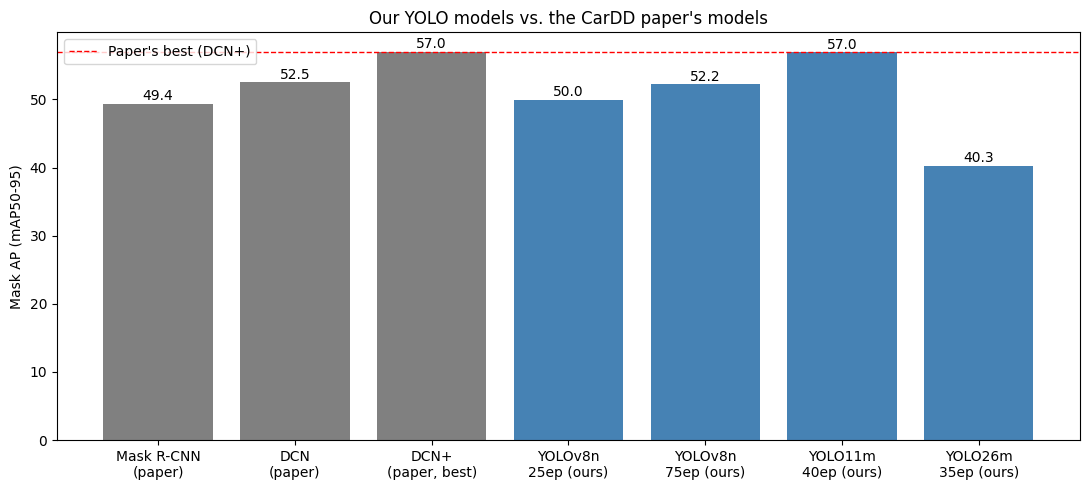

In [ ]:
# chart: our models vs. the paper's models
import matplotlib.pyplot as plt

labels = ["Mask R-CNN\n(paper)", "DCN\n(paper)", "DCN+\n(paper, best)",
          "YOLOv8n\n25ep (ours)", "YOLOv8n\n75ep (ours)",
          "YOLO11m\n40ep (ours)", "YOLO26m\n35ep (ours)"]
values = [49.4, 52.5, 57.0, 49.99, 52.25, 56.96, 40.3]
colors = ["gray", "gray", "gray", "steelblue", "steelblue", "steelblue", "steelblue"]

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, values, color=colors)
plt.ylabel("Mask AP (mAP50-95)")
plt.title("Our YOLO models vs. the CarDD paper's models")
plt.axhline(57.0, color="red", linestyle="--", linewidth=1, label="Paper's best (DCN+)")
plt.legend()
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}", ha="center")
plt.tight_layout()
plt.show()

Our best model, **YOLO11m-seg (40 epochs)**, reaches a mask AP of 56.96 — nearly matching the paper's best result (DCN+ at 57.0), despite being a much lighter, single-stage model.

## Parameter Count Comparison

| Model | Parameters | Mask mAP50-95 |
|---|---|---|
| YOLO11m-seg (ours) | ~22.4M | 0.5695 |
| DCN+ (paper's best) | ~63-64M (estimated) | 0.5700 |

Nearly identical accuracy with **~2.8x fewer parameters** — YOLO11m is far more practical for real-world deployment.

### Comparison Demo

In [ ]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image as PILImage


test_images = [
    "/content/OIP.webp",
    "/content/body-car-get-damaged-by-600nw-190287860.webp",
    "/content/fender-bender-car-crash.jpeg",
]

models_dict = {
    "YOLOv8n (25ep)": model_yolo8n_25_epoch,
    "YOLOv8n (75ep)": model_yolo8n_75_epoch,
    "YOLO11m (40ep)": model_yolo11m_40_epoch,
    "YOLO26m (35ep)": model_yolo26m_35_epoch,
}

def predict_and_annotate(model, image_path, conf=0.35):
    results = model.predict(image_path, conf=conf, verbose=False)[0]
    annotated_bgr = results.plot()
    return cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

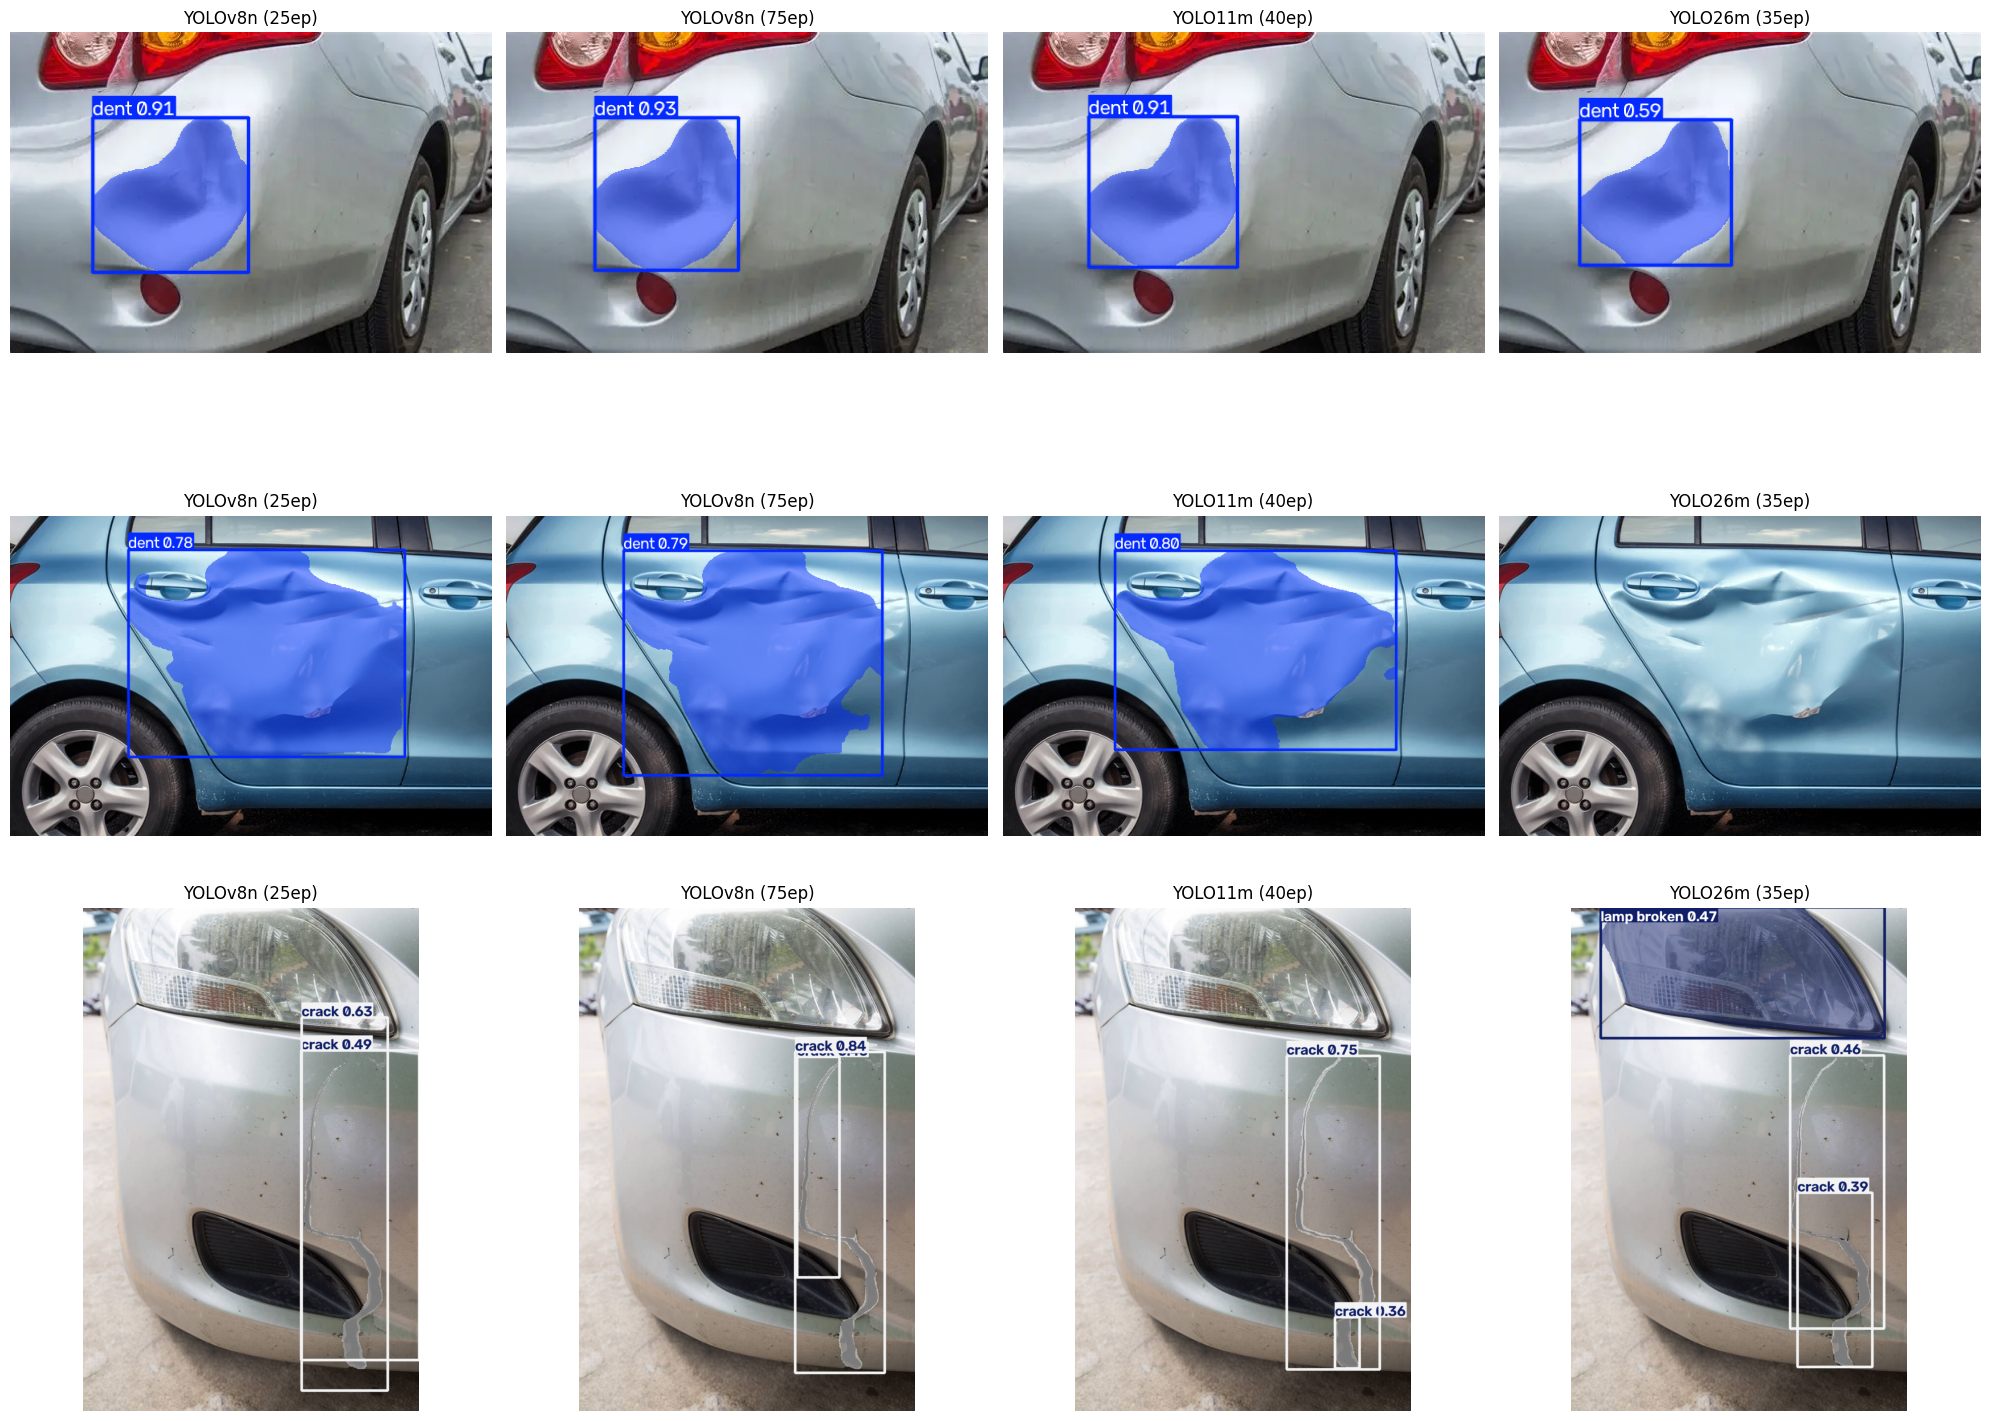

In [ ]:
# grid: rows = images, columns = models
n_images = len(test_images)
n_models = len(models_dict)

fig, axes = plt.subplots(n_images, n_models, figsize=(5 * n_models, 5 * n_images))

for row, img_path in enumerate(test_images):
    for col, (model_name, model) in enumerate(models_dict.items()):
        annotated = predict_and_annotate(model, img_path)
        ax = axes[row, col] if n_images > 1 else axes[col]
        ax.imshow(annotated)
        ax.set_title(model_name, fontsize=12)
        ax.axis("off")

plt.tight_layout()
plt.show()